In [26]:
from tools.utils import replace_minus_ones_with_prev
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns


In [27]:
processed_data_dir = Path('processed_data/tous')
file_name = processed_data_dir / 'metadata_annotated_distilbert.tsv' # _annotated_distilbert
metadata = pd.read_csv(file_name,sep='\t')
metadata['year_int'] = metadata.year.apply(lambda x: int(str(x)[:4]))
metadata.fillna('', inplace=True)

In [44]:
clause_type = 'arbitration' # 'opt-out' | 'arbitration' | 'class waiver' | 'anti-scraping' | 'modification'
threshold = 0.9
metadata[f'{clause_type}_recoded'] = 0
metadata.loc[metadata[f'prob_1_{clause_type}'] >= threshold, f'{clause_type}_recoded'] = 1

In [45]:

data = metadata.groupby(['platform','year_int'])[f'{clause_type}_recoded'].sum().astype(bool).astype(int).unstack().fillna(-1)
#data = metadata.groupby(['platform','year_int'])[clause_type].mean().unstack().fillna(-1)


<Axes: xlabel='year_int', ylabel='platform'>

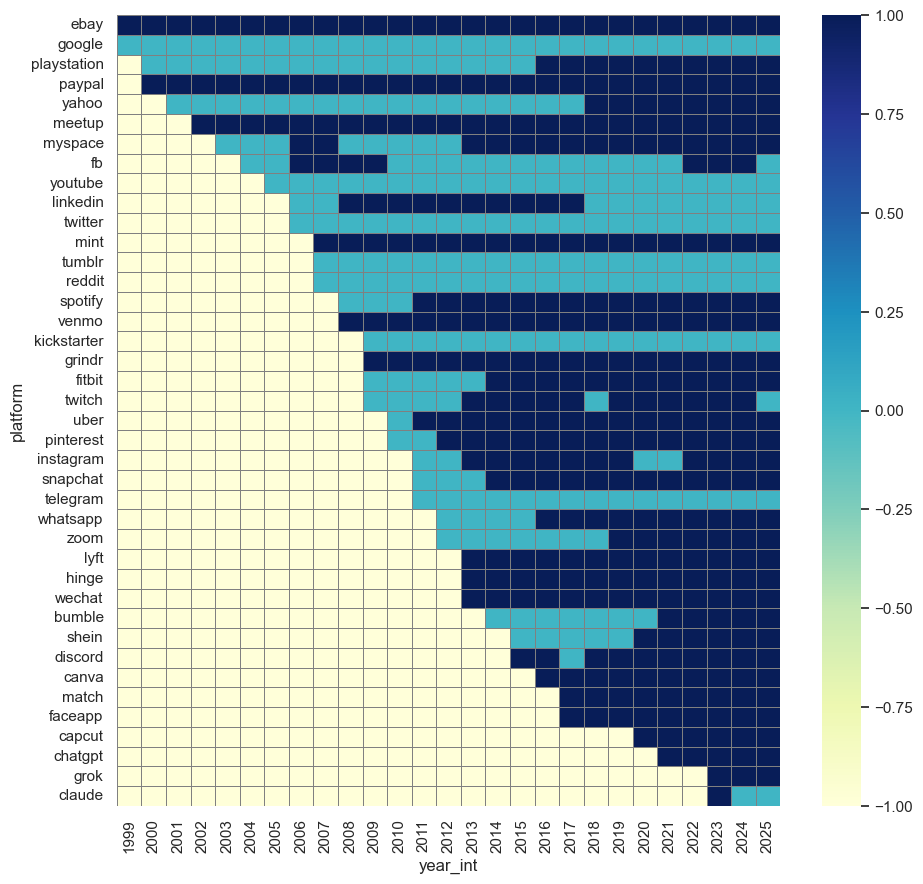

In [46]:
sns.set(rc={'figure.figsize':(10.7,10.27)})
data_replaced = replace_minus_ones_with_prev(data)
sns.heatmap(data_replaced.loc[(data_replaced > -1).sum(axis=1).sort_values(ascending=False).index],cbar=True, cmap='YlGnBu', linewidths=.5, linecolor='gray', vmin=-1, vmax=1)

## Fin